# WEEK 6 - HYPOTHESIS TESTING AND STATISTICAL ANALYSIS

Titanic Dataset

## 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import t

## 2. LOAD DATASET

In [2]:
df = pd.read_csv("tested.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (418, 12)


## 3. DATA UNDERSTANDING

In [3]:
# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
# Display last 5 rows
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [5]:
# Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 418
Number of columns: 12


In [6]:
# Column names
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [7]:
# Dataset information
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [8]:
# Descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [9]:
# Descriptive statistics including categorical columns
print("\nComplete Descriptive Statistics:")
display(df.describe(include="all"))


Complete Descriptive Statistics:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,0.363636,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.481622,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,0.000000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,0.000000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


## 4. MISSING VALUES

In [10]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [11]:
# Missing value percentages
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

display(missing_summary)

,Missing Values,Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,86,20.574163
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,1,0.239234


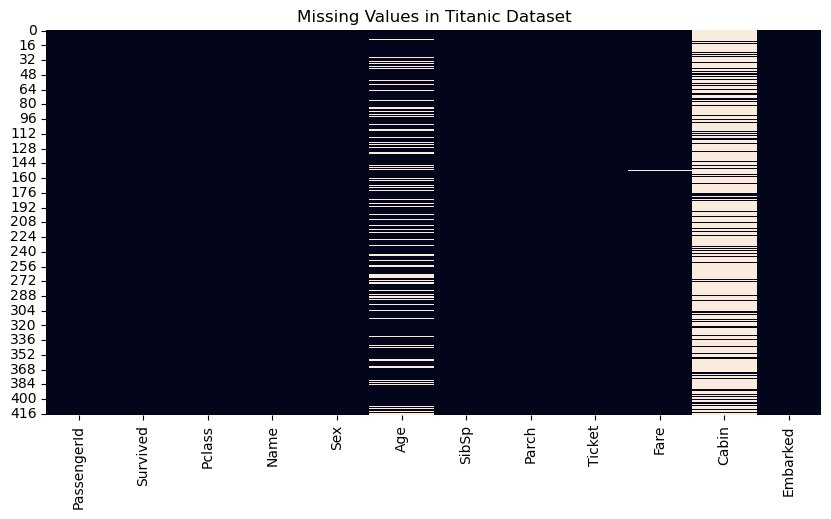

In [12]:
# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values in Titanic Dataset")
plt.show()

## 5. DUPLICATE VALUES

In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 6. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS

In [14]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


## 7. DATA CLEANING

In [15]:
# Create a copy of the original dataset
data = df.copy()

In [16]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(data.isnull().sum())

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [17]:
# Fill missing Age values with the median
# Median is less affected by extreme values than the mean.
data["Age"] = data["Age"].fillna(data["Age"].median())

In [18]:
# Fill the single missing Fare value with the median Fare
data["Fare"] = data["Fare"].fillna(data["Fare"].median())

In [19]:
# Cabin contains many missing values.
# It is not required for our hypothesis tests, so we will not use it.

In [20]:
# Verify missing values after cleaning
print("\nMissing values after cleaning:")
print(data.isnull().sum())


Missing values after cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


In [21]:
# Verify duplicates
print("\nDuplicate rows after cleaning:", data.duplicated().sum())


Duplicate rows after cleaning: 0


## 8. BASIC EXPLORATORY ANALYSIS

In [22]:
# Survival counts
print("Survival Counts:")
print(data["Survived"].value_counts())

Survival Counts:
Survived
0    266
1    152
Name: count, dtype: int64


In [23]:
# Survival percentages
survival_percentage = data["Survived"].value_counts(normalize=True) * 100

print("\nSurvival Percentage:")
print(survival_percentage)


Survival Percentage:
Survived
0    63.636364
1    36.363636
Name: proportion, dtype: float64


In [24]:
# Sex counts
print("\nPassenger Sex:")
print(data["Sex"].value_counts())


Passenger Sex:
Sex
male      266
female    152
Name: count, dtype: int64


In [25]:
# Passenger class counts
print("\nPassenger Class:")
print(data["Pclass"].value_counts().sort_index())


Passenger Class:
Pclass
1    107
2     93
3    218
Name: count, dtype: int64


## 9. CONFIDENCE INTERVAL

In [26]:
# We will calculate a 95% confidence interval for the mean passenger age.

age = data["Age"].dropna()

sample_mean = age.mean()
sample_std = age.std()
sample_size = len(age)

standard_error = sample_std / np.sqrt(sample_size)

confidence_level = 0.95
alpha = 1 - confidence_level

critical_value = t.ppf(1 - alpha / 2, df=sample_size - 1)

margin_of_error = critical_value * standard_error

lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

print("95% Confidence Interval for Mean Age")
print("--------------------------------------")
print("Sample Mean:", sample_mean)
print("Sample Size:", sample_size)
print("Standard Error:", standard_error)
print("Margin of Error:", margin_of_error)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print(
    f"\n95% Confidence Interval: "
    f"({lower_bound:.2f}, {upper_bound:.2f})"
)

95% Confidence Interval for Mean Age
--------------------------------------
Sample Mean: 29.599282296650717
Sample Size: 418
Standard Error: 0.6213616940279467
Margin of Error: 1.221391513740264
Lower Bound: 28.377890782910452
Upper Bound: 30.820673810390982

95% Confidence Interval: (28.38, 30.82)


## 10. SIMPLE CONFIDENCE INTERVAL VISUALIZATION

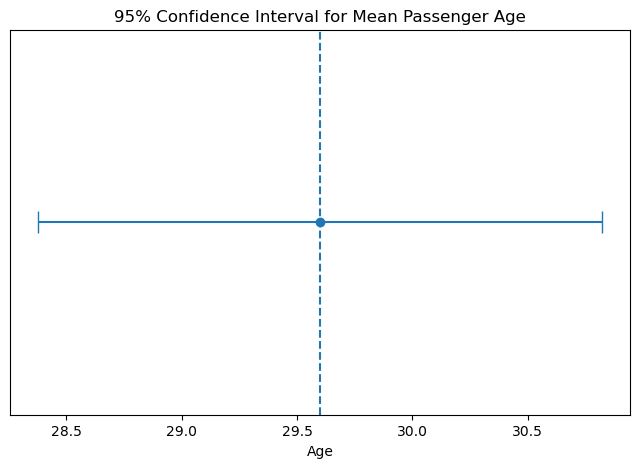

In [27]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    x=sample_mean,
    y=0,
    xerr=margin_of_error,
    fmt="o",
    capsize=8
)

plt.axvline(sample_mean, linestyle="--")

plt.title("95% Confidence Interval for Mean Passenger Age")
plt.xlabel("Age")
plt.yticks([])

plt.show()

## 11. P-VALUE EXPLANATION

In [28]:
print("""
P-VALUE EXPLANATION

A p-value tells us how unusual our observed result would be
if the null hypothesis were true.

A small p-value provides stronger evidence against the null
hypothesis.

A p-value does NOT mean the probability that the null hypothesis
is true.

Using a significance level of 0.05:

p-value < 0.05:
Reject the null hypothesis.

p-value >= 0.05:
Fail to reject the null hypothesis.
""")


P-VALUE EXPLANATION

A p-value tells us how unusual our observed result would be
if the null hypothesis were true.

A small p-value provides stronger evidence against the null
hypothesis.

A p-value does NOT mean the probability that the null hypothesis
is true.

Using a significance level of 0.05:

p-value < 0.05:
Reject the null hypothesis.

p-value >= 0.05:
Fail to reject the null hypothesis.



## 12. HYPOTHESIS TESTING CONCEPTS

In [29]:
alpha = 0.05

print("Significance Level:", alpha)

print("""
Null Hypothesis (H0):
There is no statistically significant relationship or difference.

Alternative Hypothesis (H1):
There is a statistically significant relationship or difference.

Decision Rule:
If p-value < 0.05, reject H0.
If p-value >= 0.05, fail to reject H0.
""")

Significance Level: 0.05

Null Hypothesis (H0):
There is no statistically significant relationship or difference.

Alternative Hypothesis (H1):
There is a statistically significant relationship or difference.

Decision Rule:
If p-value < 0.05, reject H0.
If p-value >= 0.05, fail to reject H0.



## 13. T-TEST

In [30]:
# Research Question:
# Is the mean age different between passengers who survived
# and passengers who did not survive?

# We use the original Age values because the t-test should not
# compare artificially filled ages between the groups.

age_data = df[["Age", "Survived"]].dropna()

survived_age = age_data[age_data["Survived"] == 1]["Age"]
not_survived_age = age_data[age_data["Survived"] == 0]["Age"]

In [31]:
print("Number of passengers with known age who survived:",
      len(survived_age))

print("Number of passengers with known age who did not survive:",
      len(not_survived_age))

Number of passengers with known age who survived: 127
Number of passengers with known age who did not survive: 205


In [32]:
print("\nMean Age of Survivors:", survived_age.mean())
print("Mean Age of Non-Survivors:", not_survived_age.mean())


Mean Age of Survivors: 30.27236220472441
Mean Age of Non-Survivors: 30.27273170731707


In [33]:
# ------------------------------------------------------------
# T-TEST HYPOTHESES
# ------------------------------------------------------------

print("""
T-TEST

Research Question:
Is the average age different between survivors and non-survivors?

H0:
There is no significant difference in mean age between survivors
and non-survivors.

H1:
There is a significant difference in mean age between survivors
and non-survivors.

Significance Level:
alpha = 0.05
""")


T-TEST

Research Question:
Is the average age different between survivors and non-survivors?

H0:
There is no significant difference in mean age between survivors
and non-survivors.

H1:
There is a significant difference in mean age between survivors
and non-survivors.

Significance Level:
alpha = 0.05



In [34]:
# Independent two-sample Welch's t-test
t_statistic, t_pvalue = ttest_ind(
    survived_age,
    not_survived_age,
    equal_var=False
)

In [35]:
print("T-Test Results")
print("----------------")
print("T-statistic:", t_statistic)
print("P-value:", t_pvalue)

T-Test Results
----------------
T-statistic: -0.0002228637852388147
P-value: 0.999822366421643


In [36]:
# Decision
if t_pvalue < alpha:
    print("\nDecision: Reject H0")
    print("There is statistically significant evidence of a difference")
    print("in mean age between survivors and non-survivors.")
else:
    print("\nDecision: Fail to reject H0")
    print("There is not enough statistical evidence to conclude that")
    print("mean age differs between survivors and non-survivors.")


Decision: Fail to reject H0
There is not enough statistical evidence to conclude that
mean age differs between survivors and non-survivors.


## 14. T-TEST VISUALIZATION

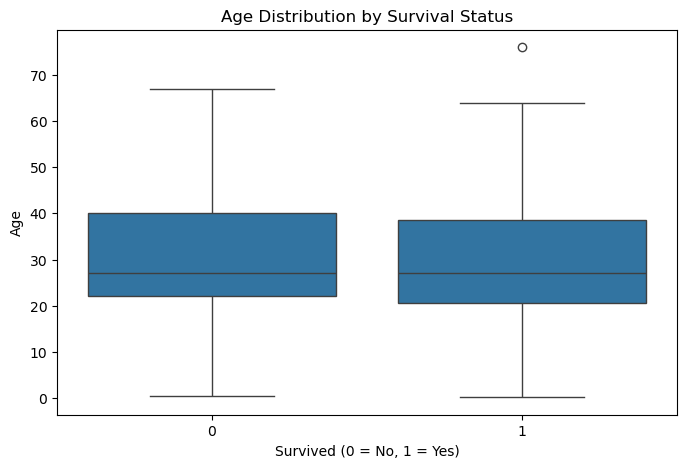

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=age_data,
    x="Survived",
    y="Age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

## 15. CHI-SQUARE TEST

In [38]:
# Research Question:
# Is passenger survival associated with passenger sex?

print("""
CHI-SQUARE TEST

Research Question:
Is passenger survival associated with passenger sex?

H0:
Passenger survival and sex are independent.

H1:
Passenger survival and sex are associated.

Significance Level:
alpha = 0.05
""")


CHI-SQUARE TEST

Research Question:
Is passenger survival associated with passenger sex?

H0:
Passenger survival and sex are independent.

H1:
Passenger survival and sex are associated.

Significance Level:
alpha = 0.05



In [39]:
# Create contingency table
contingency_table = pd.crosstab(
    data["Sex"],
    data["Survived"]
)

print("Observed Frequencies:")
display(contingency_table)

Observed Frequencies:


Survived,0,1
Sex,,
female,0,152
male,266,0


In [40]:
# Perform chi-square test
chi2_statistic, chi2_pvalue, degrees_of_freedom, expected_frequencies = chi2_contingency(
    contingency_table
)

In [41]:
print("Chi-Square Statistic:", chi2_statistic)
print("Degrees of Freedom:", degrees_of_freedom)
print("P-value:", chi2_pvalue)

Chi-Square Statistic: 413.6897405343716
Degrees of Freedom: 1
P-value: 5.767311139789629e-92


In [42]:
# Expected frequencies
expected_table = pd.DataFrame(
    expected_frequencies,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("\nExpected Frequencies:")
display(expected_table)


Expected Frequencies:


Survived,0,1
Sex,,
female,96.727273,55.272727
male,169.272727,96.727273


In [43]:
# Decision
if chi2_pvalue < alpha:
    print("\nDecision: Reject H0")
    print("There is statistically significant evidence of an association")
    print("between passenger sex and survival.")
else:
    print("\nDecision: Fail to reject H0")
    print("There is not enough statistical evidence to conclude that")
    print("passenger sex and survival are associated.")


Decision: Reject H0
There is statistically significant evidence of an association
between passenger sex and survival.


## 16. CHI-SQUARE TEST VISUALIZATION

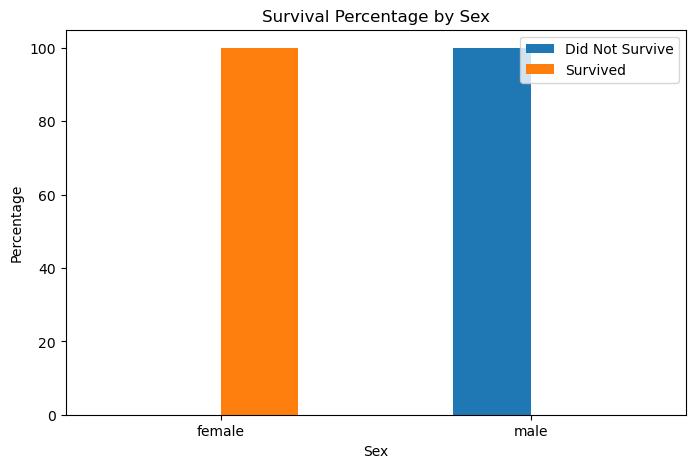

In [44]:
survival_by_sex = pd.crosstab(
    data["Sex"],
    data["Survived"],
    normalize="index"
) * 100

survival_by_sex.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Survival Percentage by Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Did Not Survive", "Survived"])

plt.show()

## 17. SURVIVAL RATE BY SEX

In [45]:
survival_rate = data.groupby("Sex")["Survived"].mean() * 100

print("Survival Rate by Sex:")
print(survival_rate)

Survival Rate by Sex:
Sex
female    100.0
male        0.0
Name: Survived, dtype: float64


## 18. A/B TESTING EXPLANATION

In [46]:
print("""
A/B TESTING

A/B testing compares two versions of something to determine
whether there is a statistically significant difference.

Example:

Group A:
Original website button

Group B:
New website button

Suppose:

Group A conversion rate = 10%
Group B conversion rate = 13%

A statistical test can determine whether the observed difference
is likely to represent a real difference or could have occurred
due to random variation.

The Titanic dataset is observational and was not designed as an
A/B experiment. Therefore, the Titanic analysis should not be
described as an actual A/B test.
""")


A/B TESTING

A/B testing compares two versions of something to determine
whether there is a statistically significant difference.

Example:

Group A:
Original website button

Group B:
New website button

Suppose:

Group A conversion rate = 10%
Group B conversion rate = 13%

A statistical test can determine whether the observed difference
is likely to represent a real difference or could have occurred
due to random variation.

The Titanic dataset is observational and was not designed as an
A/B experiment. Therefore, the Titanic analysis should not be
described as an actual A/B test.



## 19. SIMPLE A/B TESTING EXAMPLE

In [47]:
# Example business data:
# Number of conversions in two groups

group_A_conversions = 50
group_A_total = 500

group_B_conversions = 70
group_B_total = 500

group_A_rate = group_A_conversions / group_A_total
group_B_rate = group_B_conversions / group_B_total

print("A/B Testing Example")
print("-------------------")

print("Group A conversion rate:",
      group_A_rate * 100, "%")

print("Group B conversion rate:",
      group_B_rate * 100, "%")

A/B Testing Example
-------------------
Group A conversion rate: 10.0 %
Group B conversion rate: 14.000000000000002 %


In [48]:
# Two-proportion z-test using scipy
from scipy.stats import chi2_contingency

ab_table = np.array([
    [group_A_conversions, group_A_total - group_A_conversions],
    [group_B_conversions, group_B_total - group_B_conversions]
])

ab_chi2, ab_pvalue, _, _ = chi2_contingency(ab_table)

print("A/B example p-value:", ab_pvalue)

if ab_pvalue < alpha:
    print("The difference is statistically significant.")
else:
    print("The difference is not statistically significant.")

A/B example p-value: 0.0644672001586716
The difference is not statistically significant.


## 20. ADDITIONAL VISUALIZATION - SURVIVAL COUNT

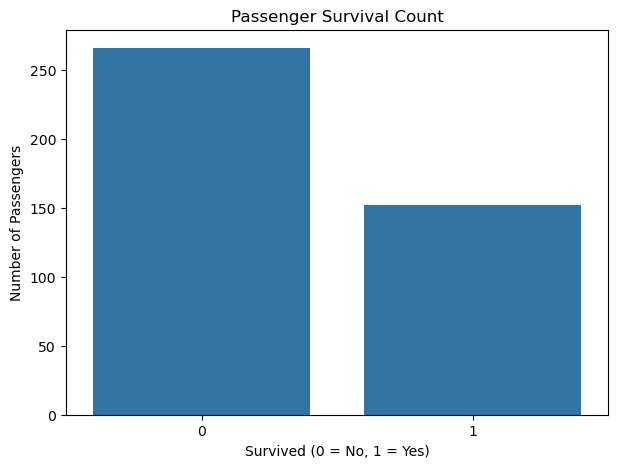

In [49]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Survived"
)

plt.title("Passenger Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

## 21. ADDITIONAL VISUALIZATION - PASSENGER CLASS

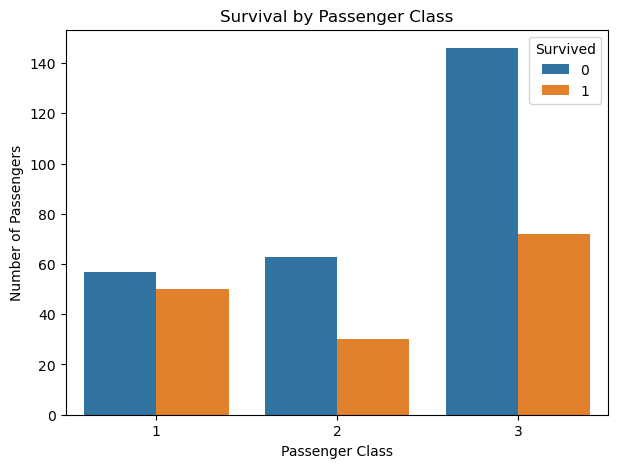

In [50]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

## 22. FINAL REAL-DATA HYPOTHESIS TEST

In [51]:
print("=" * 60)
print("FINAL REAL-DATA HYPOTHESIS TEST")
print("=" * 60)

print("""
Research Question:
Is passenger survival associated with passenger sex?

H0:
Passenger sex and survival are independent.

H1:
Passenger sex and survival are associated.

Significance Level:
alpha = 0.05

Test Used:
Chi-square test of independence
""")

print("Test Statistic:", chi2_statistic)
print("P-value:", chi2_pvalue)

FINAL REAL-DATA HYPOTHESIS TEST

Research Question:
Is passenger survival associated with passenger sex?

H0:
Passenger sex and survival are independent.

H1:
Passenger sex and survival are associated.

Significance Level:
alpha = 0.05

Test Used:
Chi-square test of independence

Test Statistic: 413.6897405343716
P-value: 5.767311139789629e-92


In [52]:
if chi2_pvalue < alpha:
    decision = "Reject H0"
    conclusion = (
        "The data provides statistically significant evidence "
        "of an association between passenger sex and survival."
    )
else:
    decision = "Fail to reject H0"
    conclusion = (
        "The data does not provide enough statistical evidence "
        "of an association between passenger sex and survival."
    )

print("Decision:", decision)
print("Conclusion:", conclusion)

Decision: Reject H0
Conclusion: The data provides statistically significant evidence of an association between passenger sex and survival.


## 23. PERCENTAGE TABLE FOR INTERPRETATION

In [53]:
percentage_table = pd.crosstab(
    data["Sex"],
    data["Survived"],
    normalize="index"
) * 100

percentage_table.columns = [
    "Did Not Survive (%)",
    "Survived (%)"
]

print("Survival Percentage by Sex:")
display(percentage_table)

Survival Percentage by Sex:


,Did Not Survive (%),Survived (%)
Sex,,
female,0.0,100.0
male,100.0,0.0


## 24. BUSINESS / DATA INTERPRETATION


**BUSINESS / DATA INTERPRETATION

The analysis investigates whether passenger survival is associated
with passenger sex.

If the chi-square test produces a statistically significant result,
the dataset provides evidence that survival outcomes were associated
with sex among the passengers represented in this dataset.

From a data science perspective, this shows how categorical
variables can be compared using a chi-square test.

However, this is an observational dataset. Statistical association
does not prove that sex itself caused the survival difference.

Other factors, such as passenger class, age, location, access to
lifeboats, and other circumstances, may also be related to survival.

Therefore, the result should be interpreted as an association rather
than a causal relationship.**


## 25. FINAL SUMMARY

**FINAL SUMMARY


1. Confidence Interval:
A 95% confidence interval was calculated for the mean passenger age.

2. Margin of Error:
The margin of error describes the amount of uncertainty around the
estimated sample mean.

3. P-value:
A p-value measures how unusual the observed result would be if the
null hypothesis were true.

4. Hypothesis Testing:
We used a significance level of alpha = 0.05 to make statistical
decisions.

5. T-Test:
An independent Welch's t-test was used to compare the mean age of
survivors and non-survivors.

6. Chi-Square Test:
A chi-square test of independence was used to investigate the
association between passenger sex and survival.

7. A/B Testing:
A/B testing was explained using a simple business example. The
Titanic dataset itself is not an A/B experiment.

8. Real-Data Analysis:
The main real-data hypothesis test investigated whether passenger
sex and survival were statistically associated.

9. Interpretation:
The results should be interpreted carefully because the Titanic
dataset is observational and statistical association does not prove
causation.**

## 26. FINAL RESULTS TABLE

In [54]:
results = pd.DataFrame({
    "Analysis": [
        "95% Confidence Interval",
        "Independent T-Test",
        "Chi-Square Test"
    ],
    "Statistic": [
        f"Mean = {sample_mean:.2f}",
        f"t = {t_statistic:.4f}",
        f"χ² = {chi2_statistic:.4f}"
    ],
    "P-Value": [
        "N/A",
        f"{t_pvalue:.6f}",
        f"{chi2_pvalue:.6f}"
    ],
    "Significance Level": [
        "95%",
        "0.05",
        "0.05"
    ]
})

display(results)

,Analysis,Statistic,P-Value,Significance Level
0,95% Confidence Interval,Mean = 29.60,N/A,95%
1,Independent T-Test,t = -0.0002,0.999822,0.05
2,Chi-Square Test,χ² = 413.6897,0.000000,0.05


**28. SAVE CLEANED DATASET** 

In [55]:
data.to_csv("cleaned_titanic_dataset.csv", index=False)

print("Cleaned dataset saved as cleaned_titanic_dataset.csv")

Cleaned dataset saved as cleaned_titanic_dataset.csv
